<a href="https://colab.research.google.com/github/antoniosolis4536-collab/MIAAD/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo_274706.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** ANTONIO ISMAEL SOLIS MARTINEZ
- **Matrícula:** 274706

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [35]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.
media = df['price'].mean()
mediana = df['price'].median()
moda = df['price'].mode()
print(f'Media: {media}')
print(f'Mediana: {mediana}')
print(f'Moda: {moda}')


Media: 152.7206871868289
Mediana: 106.0
Moda: 0    100
Name: price, dtype: int64


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_ Pues to diria que si devergen bastante debido a que son 106 y 152 aproximadamente eso me dice que algunos precios estan altos. Y referente a lo que vi en clase sobre Income, me dice que hay valores atipicos o outliers los cuales afectan la media.

---
## Actividad 2 — Dispersión (20 pts)

In [36]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.
min_price = df['price'].min()
max_price = df['price'].max()
rango = max_price - min_price
varianza = df['price'].var()
desviacion_estandar = df['price'].std()
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
IQR = q3 - q1
print(f'Rango: {rango:,.2f}')
print(f'Varianza: {varianza:,.2f}')
print(f'Desviación estándar: {desviacion_estandar:,.2f}')
print(f'Q1: ${q1}')
print(f'Q3: ${q3}')
print(f'IQR: ${IQR}')



Rango: 10,000.00
Varianza: 57,674.03
Desviación estándar: 240.15
Q1: $69.0
Q3: $175.0
IQR: $106.0


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_ El IQR para mi es el mas representativo porque describe el 50% central de los datos. El rango queda afectado por los precios maximos, por ejemplo por el valor 10,000.

---
## Actividad 3 — Forma (20 pts)

In [37]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.
asimetria = df['price'].skew()
curtosis = df['price'].kurt()
print(f'Asimetría: {asimetria:.2f}')
print(f'Curtosis: {curtosis:.2f}')



Asimetría: 19.12
Curtosis: 585.67


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_ Los resultados de asimetría y curtosis muestran que la distribución de price está fuertemente sesgada hacia la derecha y presenta colas pesadas. Esto indica la presencia de valores extremos y se relaciona directamente con los posibles outliers que se identificarán en la siguiente actividad.

---
## Actividad 4 — Visualización (30 pts)

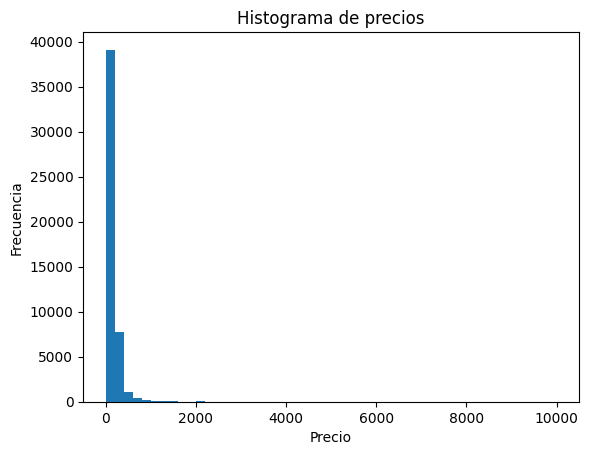

In [38]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.
df['price'].plot(kind='hist', bins=50) # se usan 50 para observar con mayor detalle. (aunque entre mas aumente sera mas detallado)
plt.title('Histograma de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

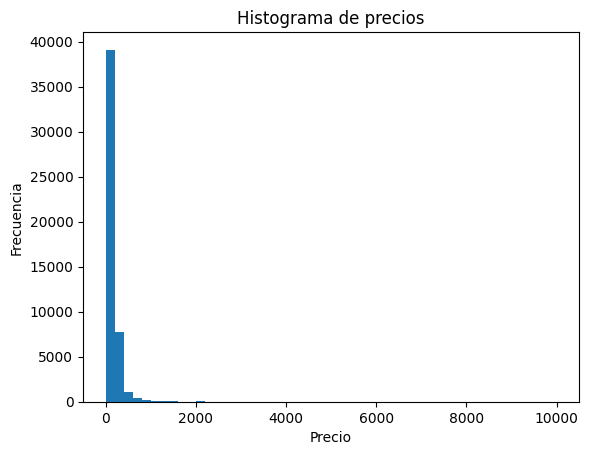

In [39]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.
plt.hist(df['price'], bins=50)
plt.title('Histograma de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()



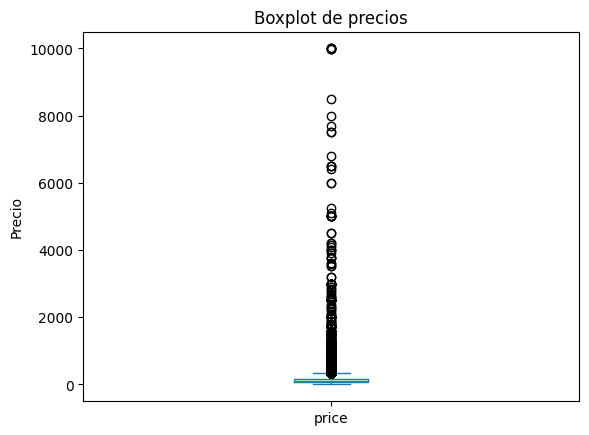

In [40]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).
df['price'].plot(kind='box')
plt.title('Boxplot de precios')
plt.ylabel('Precio')
plt.show()



**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_ El histograma muestra una mayor concentración de precios en los valores bajos y una cola larga hacia la derecha. El boxplot permite observar con mayor claridad los valores extremos. Ambas gráficas son consistentes con la asimetría positiva observada anteriormente.

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_ La media de 152.72 puede ser engañosa porque está afectada por valores extremos o altos, como el precio máximo de 10,000. La mediana de 106 representa mejor el precio típico, mientras que el IQR de 106 muestra de manera más robusta la dispersión de la mayoría de los datos. Por eso, es importante utilizar varias medidas estadísticas y no depender únicamente de la media.

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |